In [1]:
!pip install pandas==2.3.3
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 83.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
dopamine-rl 4.

# LOAD MODELS & NORMALIZATION

In [2]:
import numpy as np
import tensorflow as tf

# Base models
model_raw  = tf.keras.models.load_model("/kaggle/input/individualmodeloutputs-for-fusionmodel/run2_outputs/raw/raw_ecg_rnn_reg_dropout.h5")
model_stft = tf.keras.models.load_model("/kaggle/input/individualmodeloutputs-for-fusionmodel/run2_outputs/stft/stft_resnet50_reg_dropout.h5")
model_cwt  = tf.keras.models.load_model("/kaggle/input/individualmodeloutputs-for-fusionmodel/run2_outputs/cwt/cwt_unet_reg_dropout.h5")

# Fusion model
fusion_model = tf.keras.models.load_model("/kaggle/input/latefusionmodel/keras/default/1/late_fusion_model.h5")

# Normalization stats
raw_mean = np.load("/kaggle/input/individualmodeloutputs-for-fusionmodel/run2_outputs/raw/raw_mean.npy")
raw_std  = np.load("/kaggle/input/individualmodeloutputs-for-fusionmodel/run2_outputs/raw/raw_std.npy")

stft_mean = np.load("/kaggle/input/individualmodeloutputs-for-fusionmodel/run2_outputs/stft/stft_mean.npy")
stft_std  = np.load("/kaggle/input/individualmodeloutputs-for-fusionmodel/run2_outputs/stft/stft_std.npy")

cwt_mean = np.load("/kaggle/input/individualmodeloutputs-for-fusionmodel/run2_outputs/cwt/cwt_mean.npy")
cwt_std  = np.load("/kaggle/input/individualmodeloutputs-for-fusionmodel/run2_outputs/cwt/cwt_std.npy")

print("All models and normalization stats loaded.")

2026-03-25 21:54:57.262318: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774475697.489049      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774475697.564923      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774475698.126787      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774475698.126834      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774475698.126837      23 computation_placer.cc:177] computation placer alr

All models and normalization stats loaded.


In [3]:
# -----------------------------
# Imports
# -----------------------------
import os
import numpy as np
import pandas as pd
import wfdb
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)

# -----------------------------
# PARAMETERS
# -----------------------------
FS = 250
SEG_LEN = 2500
USE_LEAD = 0

BASE_DIR = "/kaggle/input/mit-bih-af-dataset/mit-bih-atrial-fibrillation-database-1.0.0/files"

# -----------------------------
# READ AFDB RECORDS
# -----------------------------
def read_afdb_records(base_dir):
    records = sorted({
        f.replace(".dat", "")
        for f in os.listdir(base_dir)
        if f.endswith(".dat")
    })

    Signals, Labels, Ids = [], [], []

    for rec in records:
        try:
            record = wfdb.rdrecord(os.path.join(base_dir, rec))
            sig = record.p_signal[:, USE_LEAD].astype(np.float32)

            ann = wfdb.rdann(os.path.join(base_dir, rec), "atr")

            rhythm_starts, rhythm_labels = [], []
            for i, note in enumerate(ann.aux_note):
                if note in ["(N", "(AFIB"]:
                    rhythm_starts.append(ann.sample[i])
                    rhythm_labels.append("N" if note == "(N" else "A")

            rhythm_starts.append(len(sig))

            for i in range(len(rhythm_labels)):
                seg = sig[rhythm_starts[i]:rhythm_starts[i+1]]
                if len(seg) >= SEG_LEN:
                    Signals.append(seg)
                    Labels.append(rhythm_labels[i])
                    Ids.append(rec)

        except Exception as e:
            print(f"Skipping {rec}: {e}")

    return Signals, pd.Series(Labels, dtype="category"), np.array(Ids)

# -----------------------------
# SEGMENTATION (USED INSIDE FOLDS)
# -----------------------------
def segment_signals_from_df(df, seg_len=SEG_LEN):
    X, Y = [], []
    for _, row in df.iterrows():
        x, y = row["signal"], row["label"]
        for i in range(len(x) // seg_len):
            X.append(x[i*seg_len:(i+1)*seg_len])
            Y.append(y)
    return X, Y

# -----------------------------
# LOAD DATA
# -----------------------------
Signals, Labels, Ids = read_afdb_records(BASE_DIR)

records_df = pd.DataFrame({
    "id": Ids,
    "signal": Signals,
    "label": Labels
})

print("\nTotal rhythm intervals:", len(records_df))
print("Overall label distribution:", Counter(records_df["label"]))

# -----------------------------
# HOLD-OUT TEST SET (PATIENT-WISE)
# -----------------------------
unique_ids = records_df["id"].unique()

trainval_ids, test_ids = train_test_split(
    unique_ids,
    test_size=0.2,
    random_state=42
)

trainval_df = records_df[records_df["id"].isin(trainval_ids)].reset_index(drop=True)
test_df     = records_df[records_df["id"].isin(test_ids)].reset_index(drop=True)

print(f"\nPatients:")
print(f"Train+Val: {len(trainval_ids)}")
print(f"Test     : {len(test_ids)}")

# -----------------------------
# PREPARE TEST SET (ONCE)
# -----------------------------
XTest, YTest = segment_signals_from_df(test_df)

def reshape_raw(X, seq_len=SEG_LEN):
    return np.array(X, dtype=np.float32).reshape(-1, seq_len, 1)

XTest_raw = reshape_raw(XTest)

le = LabelEncoder()
YTest_enc = le.fit_transform(YTest)

ohe = OneHotEncoder(sparse_output=False)
YTest_oh = ohe.fit_transform(YTest_enc.reshape(-1, 1))

class_names = le.classes_

print("\nTest segments:", len(XTest))
print("Test label distribution:", Counter(YTest))


Total rhythm intervals: 550
Overall label distribution: Counter({'N': 285, 'A': 265})

Patients:
Train+Val: 18
Test     : 5

Test segments: 18372
Test label distribution: Counter({'N': 10784, 'A': 7588})


# RESAMPLE + MATCH SEGMENT LENGTH

In [4]:
from scipy.signal import resample

TARGET_FS = 300
TARGET_LEN = 9000
ORIG_FS = 250

def resample_and_fix_length(sig):
    sig = resample(sig, int(len(sig) * TARGET_FS / ORIG_FS))

    if len(sig) < TARGET_LEN:
        sig = np.pad(sig, (0, TARGET_LEN - len(sig)))
    else:
        sig = sig[:TARGET_LEN]

    return sig.astype(np.float32)

# SELECT 1000 BALANCED SAMPLES (500 N + 500 AF)

In [5]:
df_N = records_df[records_df["label"] == "N"]
df_A = records_df[records_df["label"] == "A"]

n = min(500, len(df_N), len(df_A))
print(f"Sampling {n} per class")

df_eval = pd.concat([
    df_N.sample(n=n, random_state=42),
    df_A.sample(n=n, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Selected samples:", Counter(df_eval["label"]))

Sampling 265 per class
Selected samples: Counter({'N': 265, 'A': 265})


In [6]:
from scipy.signal import resample

TARGET_FS = 300
ORIG_FS = 250
TARGET_LEN = 9000

def resample_and_fix_length(sig):
    sig = resample(sig, int(len(sig) * TARGET_FS / ORIG_FS))

    if len(sig) < TARGET_LEN:
        sig = np.pad(sig, (0, TARGET_LEN - len(sig)))
    else:
        sig = sig[:TARGET_LEN]

    return sig.astype(np.float32)

X_raw = np.stack([
    resample_and_fix_length(x)
    for x in df_eval["signal"]
])[..., np.newaxis]

print("X_raw shape:", X_raw.shape)   # (N, 9000, 1)

X_raw shape: (530, 9000, 1)


In [7]:
TARGET_LEN = 9000

def force_len_9000(x):
    x = x.squeeze()

    if x.shape[0] != TARGET_LEN:
        if x.shape[0] > TARGET_LEN:
            x = x[:TARGET_LEN]
        else:
            x = np.pad(x, (0, TARGET_LEN - x.shape[0]))

    return x.astype(np.float32)

# RAW ECG PREPROCESSING

In [8]:
TARGET_LEN = 9000

def ensure_length_9000(x):
    if len(x) < TARGET_LEN:
        x = np.pad(x, (0, TARGET_LEN - len(x)))
    else:
        x = x[:TARGET_LEN]
    return x.astype(np.float32)

X_raw_fixed = np.stack([
    ensure_length_9000(x.squeeze())
    for x in X_raw
])[..., np.newaxis]

print("RAW fixed shape:", X_raw_fixed.shape)

RAW fixed shape: (530, 9000, 1)


# STFT PREPROCESSING

In [9]:
from scipy.signal import stft

FS = 300
NFFT = 256
HOP = 32
WIN = "hann"
TARGET_LEN = 9000

def force_len_9000(x):
    x = x.squeeze()
    if x.shape[0] > TARGET_LEN:
        x = x[:TARGET_LEN]
    elif x.shape[0] < TARGET_LEN:
        x = np.pad(x, (0, TARGET_LEN - x.shape[0]))
    return x.astype(np.float32)

def stft_image_exact(x):
    x = force_len_9000(x)

    _, _, Zxx = stft(
        x,
        fs=FS,
        window=WIN,
        nperseg=NFFT,
        noverlap=NFFT - HOP,
        boundary="zeros",     # 🔑 THIS IS THE FIX
        padded=True           # 🔑 THIS IS THE FIX
    )

    return np.log1p(np.abs(Zxx)).astype(np.float32)

X_stft = np.stack([
    stft_image_exact(x)
    for x in X_raw
])[..., np.newaxis]

print("STFT shape:", X_stft.shape)

STFT shape: (530, 129, 283, 1)


In [10]:
X_stft = (X_stft - stft_mean) / stft_std

y_prob_stft = model_stft.predict(X_stft, verbose=0)[:, 1]

I0000 00:00:1774475830.116081      80 service.cc:152] XLA service 0x7bdd0008d5b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774475830.116124      80 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774475830.116129      80 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774475831.089763      80 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774475836.902642      80 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


# CWT PREPROCESSING

In [11]:
import pywt

FS = 300
SCALES = np.arange(1, 65)   # 64 scales
TARGET_LEN = 9000

def force_len_9000(x):
    x = x.squeeze()
    if x.shape[0] > TARGET_LEN:
        x = x[:TARGET_LEN]
    elif x.shape[0] < TARGET_LEN:
        x = np.pad(x, (0, TARGET_LEN - x.shape[0]))
    return x.astype(np.float32)

def cwt_image_exact(x):
    x = force_len_9000(x)

    coeffs, _ = pywt.cwt(
        x,
        SCALES,
        "morl",
        sampling_period=1 / FS
    )

    power = np.log1p(np.abs(coeffs) ** 2)

    # 🔑 THIS IS THE MISSING STEP (MATCHES TRAINING)
    power = power[:, ::2]     # 9000 → 4500

    return power.astype(np.float32)

# Build CWT dataset
X_cwt = np.stack([
    cwt_image_exact(x)
    for x in X_raw
])[..., np.newaxis]

print("CWT shape:", X_cwt.shape)

CWT shape: (530, 64, 4500, 1)


In [12]:
X_cwt = (X_cwt - cwt_mean) / cwt_std

y_prob_cwt = model_cwt.predict(X_cwt, verbose=0)[:, 1]

# BASE MODEL PREDICTIONS

In [13]:
y_prob_raw  = model_raw.predict(X_raw,  verbose=0).ravel()
y_prob_stft = model_stft.predict(X_stft, verbose=0)[:, 1]
y_prob_cwt  = model_cwt.predict(X_cwt,  verbose=0)[:, 1]

In [14]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode ground truth
le = LabelEncoder()
y_true = le.fit_transform(df_eval["label"])

def evaluate_model(y_prob, name, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    spec = tn / (tn + fp + 1e-8)
    f1 = f1_score(y_true, y_pred)
    gmean = np.sqrt(rec * spec)

    print(f"\n=== {name} ===")
    print(f"Accuracy     : {acc:.4f}")
    print(f"Precision    : {prec:.4f}")
    print(f"Recall       : {rec:.4f}")
    print(f"Specificity  : {spec:.4f}")
    print(f"F1-score     : {f1:.4f}")
    print(f"G-Mean       : {gmean:.4f}")

In [15]:
evaluate_model(y_prob_raw,  "RAW MODEL")
evaluate_model(y_prob_stft, "STFT MODEL")
evaluate_model(y_prob_cwt,  "CWT MODEL")


=== RAW MODEL ===
Accuracy     : 0.7547
Precision    : 0.7733
Recall       : 0.7208
Specificity  : 0.7887
F1-score     : 0.7461
G-Mean       : 0.7540

=== STFT MODEL ===
Accuracy     : 0.8830
Precision    : 0.9356
Recall       : 0.8226
Specificity  : 0.9434
F1-score     : 0.8755
G-Mean       : 0.8810

=== CWT MODEL ===
Accuracy     : 0.4717
Precision    : 0.4847
Recall       : 0.8981
Specificity  : 0.0453
F1-score     : 0.6296
G-Mean       : 0.2017


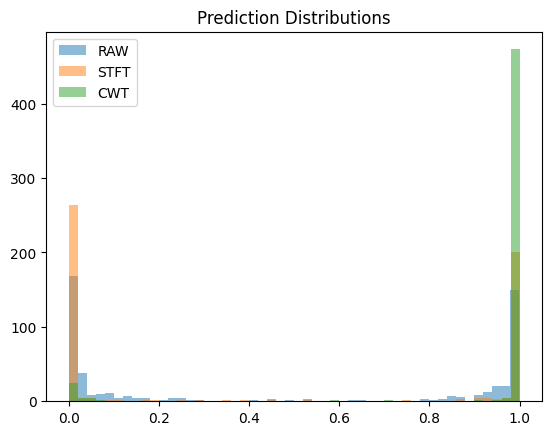

In [16]:
import matplotlib.pyplot as plt

plt.hist(y_prob_raw, bins=50, alpha=0.5, label="RAW")
plt.hist(y_prob_stft, bins=50, alpha=0.5, label="STFT")
plt.hist(y_prob_cwt, bins=50, alpha=0.5, label="CWT")
plt.legend()
plt.title("Prediction Distributions")
plt.show()

In [17]:
X_fusion = np.column_stack([y_prob_raw, y_prob_stft, y_prob_cwt])
y_prob_fused = fusion_model.predict(X_fusion, verbose=0).ravel()

In [18]:
import pandas as pd

def get_metrics(y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    spec = tn / (tn + fp + 1e-8)
    f1 = f1_score(y_true, y_pred)
    gmean = np.sqrt(rec * spec)

    return [acc, prec, rec, spec, f1, gmean]


results = pd.DataFrame(
    [
        ["RAW",   *get_metrics(y_prob_raw, 0.5)],
        ["STFT",  *get_metrics(y_prob_stft, 0.5)],
        ["CWT",   *get_metrics(y_prob_cwt, 0.5)],
        ["FUSION",*get_metrics(y_prob_fused, 0.51)]
    ],
    columns=["Model", "Accuracy", "Precision", "Recall", "Specificity", "F1", "G-Mean"]
)

print("\n=== MODEL COMPARISON ===")
display(results)


=== MODEL COMPARISON ===


,Model,Accuracy,Precision,Recall,Specificity,F1,G-Mean
0,RAW,0.754717,0.773279,0.720755,0.788679,0.746094,0.753952
1,STFT,0.883019,0.935622,0.822642,0.943396,0.875502,0.880952
2,CWT,0.471698,0.484725,0.898113,0.045283,0.629630,0.201666
3,FUSION,0.883019,0.904382,0.856604,0.909434,0.879845,0.882624


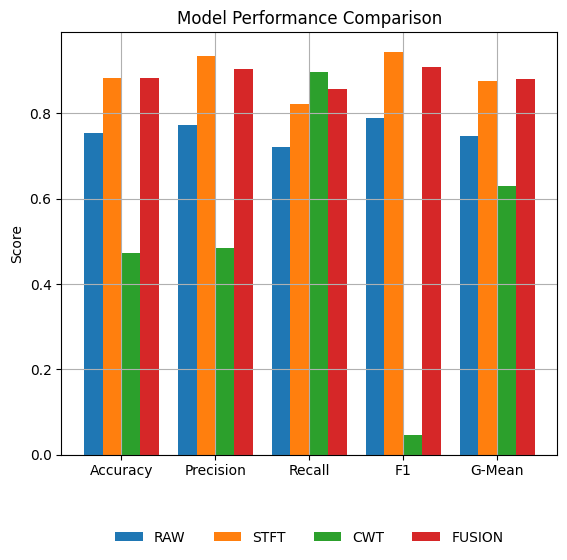

In [19]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1", "G-Mean"]

x = np.arange(len(metrics))
width = 0.2

plt.figure()

plt.bar(x - 1.5*width, results.iloc[0, 1:6], width, label="RAW")
plt.bar(x - 0.5*width, results.iloc[1, 1:6], width, label="STFT")
plt.bar(x + 0.5*width, results.iloc[2, 1:6], width, label="CWT")
plt.bar(x + 1.5*width, results.iloc[3, 1:6], width, label="FUSION")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.grid()

# 🔽 Move legend below plot
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),  # (x, y)
    ncol=4,                       # horizontal layout
    frameon=False
)

# 🔽 Add space at bottom so legend isn't cut
plt.subplots_adjust(bottom=0)

plt.show()

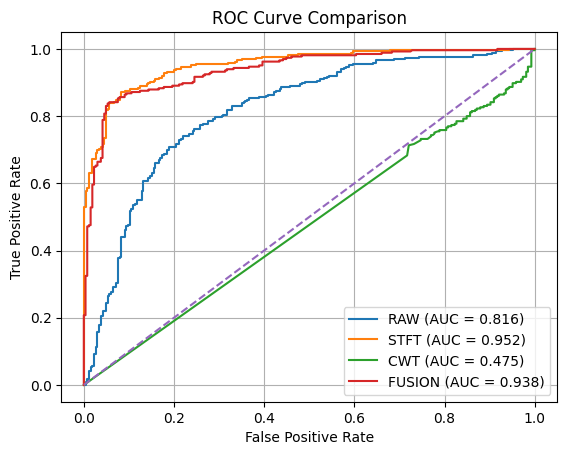

In [20]:
from sklearn.metrics import roc_curve, auc

plt.figure()

# RAW
fpr, tpr, _ = roc_curve(y_true, y_prob_raw)
plt.plot(fpr, tpr, label=f"RAW (AUC = {auc(fpr,tpr):.3f})")

# STFT
fpr, tpr, _ = roc_curve(y_true, y_prob_stft)
plt.plot(fpr, tpr, label=f"STFT (AUC = {auc(fpr,tpr):.3f})")

# CWT
fpr, tpr, _ = roc_curve(y_true, y_prob_cwt)
plt.plot(fpr, tpr, label=f"CWT (AUC = {auc(fpr,tpr):.3f})")

# FUSION
fpr, tpr, _ = roc_curve(y_true, y_prob_fused)
plt.plot(fpr, tpr, label=f"FUSION (AUC = {auc(fpr,tpr):.3f})")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()

plt.show()